# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [2]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [3]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
tox.head()

,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


In [4]:
#tox.notna().sum()
#tox.duplicated().sum()
tox.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   smiles  7376 non-null   object 
 1   ld_50   7376 non-null   float64
dtypes: float64(1), object(1)
memory usage: 115.4+ KB


2) Calculate descriptors

In [5]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [desc[1](mol) for desc in Descriptors._descList]

X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)
X_md = X_md.dropna()

y = tox["ld_50"]

[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerator
[13:13:25] DEPRECATION WARNING: please use MorganGenerat

In [6]:
#X_md.head()
X_md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Columns: 210 entries, MaxAbsEStateIndex to fr_urea
dtypes: float64(106), int64(104)
memory usage: 11.8 MB


3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [14]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)

tox.head()

,smiles,ld_50,scaffold
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505,c1ccc(N=[NH+]c2ccccc2)cc1
1,BrC(Br)Br,2.343,
2,C=CBr,2.330,
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465,c1ccc(-c2ccccc2)cc1
4,S=C=Nc1ccc(Br)cc1,2.729,c1ccccc1


In [16]:
tox.dropna()
tox.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   smiles    7376 non-null   object 
 1   ld_50     7376 non-null   float64
 2   scaffold  7376 non-null   object 
dtypes: float64(1), object(2)
memory usage: 173.0+ KB


OneHotEncoder for the Murcko scaffolds:

In [11]:
scaffold_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_scaf_encoded = scaffold_encoder.fit_transform(tox[["scaffold"]])
X_scaf = pd.DataFrame(
    X_scaf_encoded,
    columns=scaffold_encoder.get_feature_names_out(["scaffold"]),
    index=tox.index,
)

X_scaf.head()
X_scaf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Columns: 1677 entries, scaffold_ to scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21
dtypes: float64(1677)
memory usage: 94.4 MB


Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [17]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "aromatic_ring": "a"
}

In [18]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)

5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [20]:
X_fg.index = tox.index

feature_sets = {
    "X_md": X_md,
    "X_scaf": X_scaf,
    "X_fg": X_fg,
    "X_md_scaf": pd.concat([X_md, X_scaf], axis=1),
    "X_md_scaf_fg": pd.concat([X_md, X_scaf, X_fg], axis=1),
}

def evaluate_feature_set(X, y, random_state=42):
    X = X.loc[:, ~X.columns.duplicated()].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y.loc[X.index], test_size=0.2, random_state=random_state
    )
    model = RandomForestRegressor(n_estimators=300, random_state=random_state)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return r2_score(y_test, y_pred)

baseline_results = pd.Series(
    {name: evaluate_feature_set(X, y) for name, X in feature_sets.items()},
    name="r2_before_pruning",
).sort_values(ascending=False)

best_name = baseline_results.idxmax()
X_best = feature_sets[best_name].loc[:, ~feature_sets[best_name].columns.duplicated()].copy()


In [29]:
baseline_results

X_md            0.617751
X_md_scaf       0.612804
X_md_scaf_fg    0.612027
X_scaf          0.208037
X_fg            0.026434
Name: r2_before_pruning, dtype: float64

In [32]:
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.01)
X_var = pd.DataFrame(
    var_selector.fit_transform(X_best),
    columns=X_best.columns[var_selector.get_support()],
    index=X_best.index,
)

corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
X_pruned = X_var.drop(columns=to_drop)

pruned_r2 = evaluate_feature_set(X_pruned, y)

comparison = pd.DataFrame(
    {
        "r2_before_pruning": baseline_results,
    }
)
comparison.loc[best_name, "r2_after_pruning"] = pruned_r2
comparison.loc[best_name, "n_features_before"] = X_best.shape[1]
comparison.loc[best_name, "after_variance_filter"] = X_var.shape[1]
comparison.loc[best_name, "n_features_after"] = X_pruned.shape[1]

print(f"Best feature set before pruning: {best_name}")
print(f"Removed {X_best.shape[1] - X_var.shape[1]} low-variance features.")
print(f"Removed {len(to_drop)} highly correlated features.")

comparison


Best feature set before pruning: X_md
Removed 24 low-variance features.
Removed 39 highly correlated features.


,r2_before_pruning,r2_after_pruning,n_features_before,after_variance_filter,n_features_after
X_md,0.617751,0.623774,210.0,186.0,147.0
X_md_scaf,0.612804,NaN,NaN,NaN,NaN
X_md_scaf_fg,0.612027,NaN,NaN,NaN,NaN
X_scaf,0.208037,NaN,NaN,NaN,NaN
X_fg,0.026434,NaN,NaN,NaN,NaN


6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [33]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
empty_fp = DataStructs.ExplicitBitVect(2048)

def mols_to_fingerprints(mols, generator, fp_size=2048):
    fps = []
    fp_array = np.zeros((len(mols), fp_size), dtype=int)

    for i, mol in enumerate(mols):
        fp = generator.GetFingerprint(mol) if mol is not None else empty_fp
        fps.append(fp)
        DataStructs.ConvertToNumpyArray(fp, fp_array[i])

    return fps, fp_array

smiles_mols = tox["smiles"].apply(Chem.MolFromSmiles)
scaffold_mols = tox["scaffold"].apply(Chem.MolFromSmiles)

fps_smiles, X_fp_smiles = mols_to_fingerprints(smiles_mols, morgan_gen)
fps_scaf, X_fp_scaf = mols_to_fingerprints(scaffold_mols, morgan_gen)

X_fp_smiles = pd.DataFrame(X_fp_smiles, index=tox.index)
X_fp_scaf = pd.DataFrame(X_fp_scaf, index=tox.index)

print("Full-molecule fingerprint matrix:", X_fp_smiles.shape)
print("Scaffold fingerprint matrix:", X_fp_scaf.shape)


Full-molecule fingerprint matrix: (7376, 2048)
Scaffold fingerprint matrix: (7376, 2048)


7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [34]:
def analyze_fingerprint_space(
    fps,
    cutoff=0.6,
    min_cluster_size=5,
    n_neighbors=15,
    min_dist=0.1,
    fp_size=2048,
):
    nfps = len(fps)
    dists = []

    for i in range(1, nfps):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - x for x in sims])

    clusters = Butina.ClusterData(dists, nfps, cutoff, isDistData=True)
    clusters_filtered = [cluster for cluster in clusters if len(cluster) >= min_cluster_size]

    butina_labels = np.full(nfps, -1)
    for cluster_id, cluster in enumerate(clusters_filtered):
        for mol_id in cluster:
            butina_labels[mol_id] = cluster_id

    fp_array = np.zeros((nfps, fp_size), dtype=int)
    for i, fp in enumerate(fps):
        DataStructs.ConvertToNumpyArray(fp, fp_array[i])

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=42,
    )
    umap_emb = reducer.fit_transform(fp_array)

    return {
        "clusters": clusters,
        "clusters_filtered": clusters_filtered,
        "labels": butina_labels,
        "fp_array": fp_array,
        "embedding": umap_emb,
    }

fingerprint_results = {
    "Full molecule": analyze_fingerprint_space(fps_smiles),
    "Scaffold": analyze_fingerprint_space(fps_scaf),
}

print("Comparison prepared for:", ", ".join(fingerprint_results.keys()))

/Users/raphaeland./opt/anaconda3/envs/DAC_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/raphaeland./opt/anaconda3/envs/DAC_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Comparison prepared for: Full molecule, Scaffold


In [35]:
cluster_summary = pd.DataFrame(
    {
        name: {
            "clusters_total": len(result["clusters"]),
            "clusters_kept": len(result["clusters_filtered"]),
            "mean_cluster_size": np.mean([len(c) for c in result["clusters_filtered"]]) if result["clusters_filtered"] else 0,
            "max_cluster_size": max([len(c) for c in result["clusters_filtered"]], default=0),
            "unclustered_points": int(np.sum(result["labels"] == -1)),
        }
        for name, result in fingerprint_results.items()
    }
).T

cluster_summary

,clusters_total,clusters_kept,mean_cluster_size,max_cluster_size,unclustered_points
Full molecule,2408.0,334.0,12.769461,112.0,3111.0
Scaffold,747.0,161.0,40.273292,1936.0,892.0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [36]:
umap_emb_smiles = fingerprint_results["Full molecule"]["embedding"]
umap_emb_scaf = fingerprint_results["Scaffold"]["embedding"]

butina_labels_smiles = fingerprint_results["Full molecule"]["labels"]
butina_labels_scaf = fingerprint_results["Scaffold"]["labels"]

In [37]:
print("Full molecule UMAP shape:", umap_emb_smiles.shape)
print("Scaffold UMAP shape:", umap_emb_scaf.shape)

Full molecule UMAP shape: (7376, 2)
Scaffold UMAP shape: (7376, 2)


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

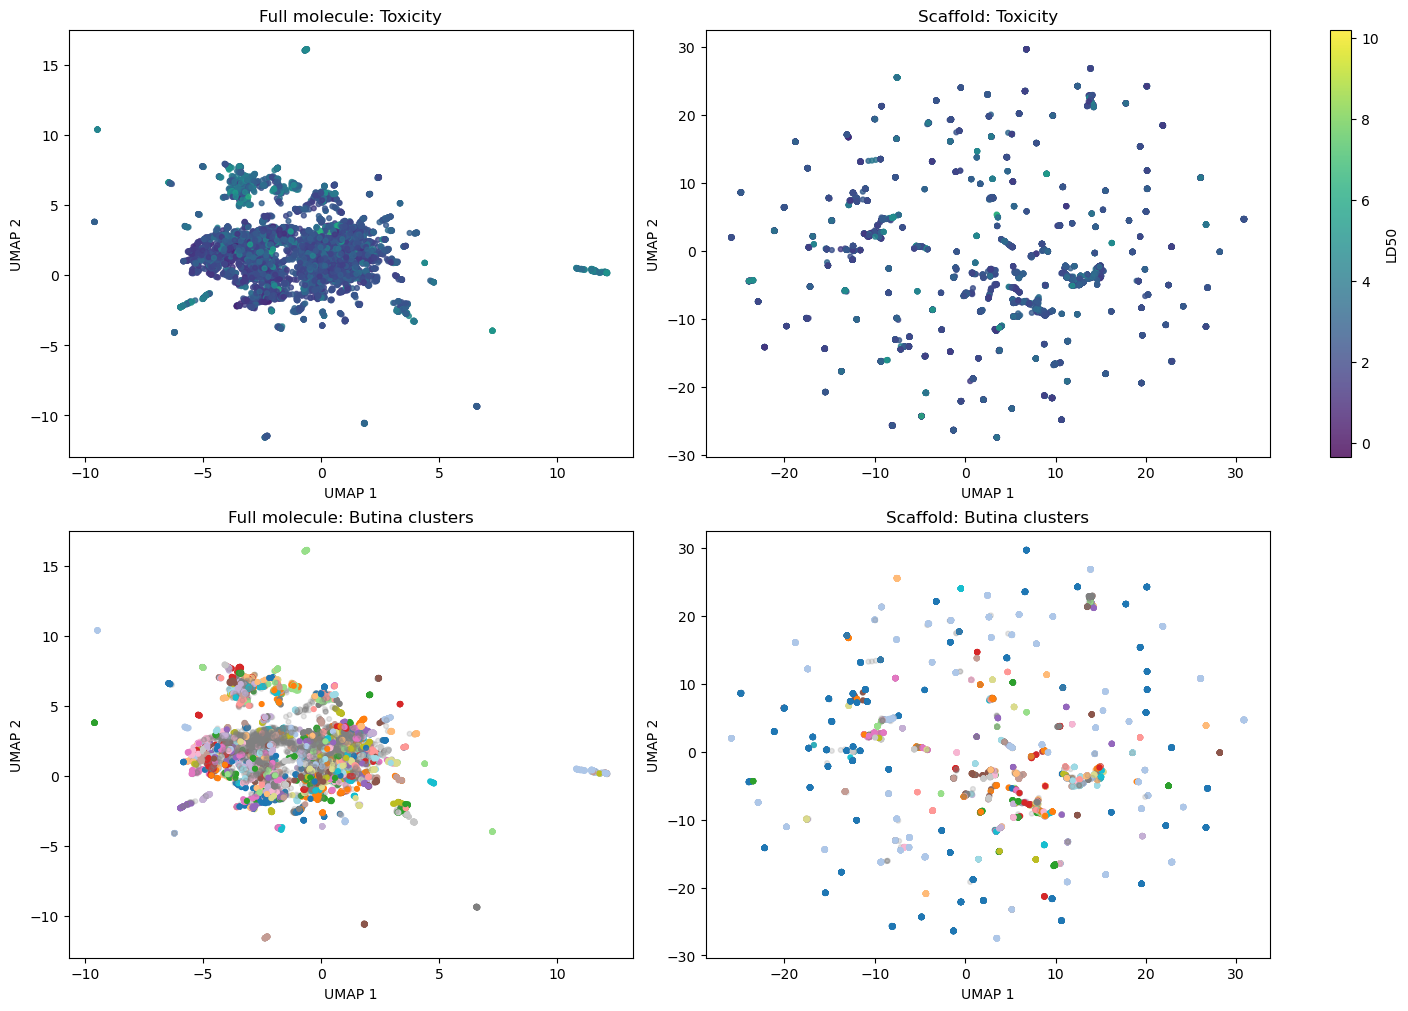

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
toxicity = tox["ld_50"].to_numpy()
tox_min, tox_max = toxicity.min(), toxicity.max()

def cluster_colors(labels):
    cmap = plt.get_cmap("tab20")
    colors = []
    for label in labels:
        if label == -1:
            colors.append("grey")
        else:
            colors.append(cmap(label % cmap.N))
    return colors

def cluster_alphas(labels, noise_alpha=0.2, cluster_alpha=1):
    return [noise_alpha if label == -1 else cluster_alpha for label in labels]

toxicity_data = [
    ("Full molecule", umap_emb_smiles),
    ("Scaffold", umap_emb_scaf),
]

cluster_data = [
    ("Full molecule", umap_emb_smiles, butina_labels_smiles),
    ("Scaffold", umap_emb_scaf, butina_labels_scaf),
]

for col, (title, embedding) in enumerate(toxicity_data):
    tox_plot = axes[0, col].scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=toxicity,
        cmap="viridis",
        s=12,
        alpha=0.8,
        vmin=tox_min,
        vmax=tox_max,
    )
    axes[0, col].set_title(f"{title}: Toxicity")
    axes[0, col].set_xlabel("UMAP 1")
    axes[0, col].set_ylabel("UMAP 2")

for col, (title, embedding, labels) in enumerate(cluster_data):
    axes[1, col].scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=cluster_colors(labels),
        s=12,
        alpha=cluster_alphas(labels),
    )
    axes[1, col].set_title(f"{title}: Butina clusters")
    axes[1, col].set_xlabel("UMAP 1")
    axes[1, col].set_ylabel("UMAP 2")

fig.colorbar(tox_plot, ax=axes[0, :], label="LD50")
plt.show()

#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?
2) Is the One-Hot Encoding needed in this case?
3) Did the feature filtering (variance, correlation) have an improving effect? Explain!
4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?
5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.
6) When might scaffolding prove useful?
7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?


#### Answers
1. X_md performed best (R2 = 0.618). X_md_scaf and X_md_scaf_fg were slightly worse, while X_scaf (0.208) and X_fg (0.026) were much weaker. Probably becasue X_md has the most complete describtion of the molecules. X_scaf is too course and X_fg is very sparce and simple

2. Yes for scaffolds and functional groups in the regression task, because they are categorical. For Morgan fingerprints, no one-hot encoding is needed tho

3. Yes, but only slightly: pruning improved X_md from 0.6178 to 0.6238 after removing 24 low-variance and 39 highly correlated features.

4. A clean solution would be a reusable pipeline: feature generation -> optional filtering -> model training -> evaluation, with the same split and metric for every feature set.

5. Full-molecule fingerprints gave many more, smaller clusters, while scaffold fingerprints gave fewer, much larger clusters. The scaffold representation removes side-chain detail, so molecules look more similar and cluster together more easily.

6. Scaffolding is useful when you want to study chemotypes, shared cores, or structure families instead of fine structural differences.

7. Toxicity appears only weakly correlated with structure: there may be local trends in UMAP space, but no strong global separation.
